# 04. Đánh giá & So sánh mô hình

Notebook này thực hiện các phân tích đánh giá chi tiết cho các mô hình:
- Tải tệp lưu trữ các giá trị dự báo sinh ra từ bước trước.
- Tính toán các chỉ số sai số MAE, RMSE, MAPE cho từng mô hình trên tập kiểm thử.
- Tổng hợp bảng so sánh hiệu năng và lưu vào tệp `results/metrics.csv`.
- Trực quan hóa các đường dự báo so với giá trị thực tế và lưu đồ thị vào thư mục `figures/`.

In [1]:
import sys
sys.path.append('../')

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from src.evaluation import calculate_metrics

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (14, 6)

## 1. Tải kết quả dự đoán

In [2]:
predictions_path = "../results/predictions.csv"
pred_df = pd.read_csv(predictions_path)
pred_df["date"] = pd.to_datetime(pred_df["date"])
pred_df.head()

,date,y_true,naive,moving_average,linear_regression_baseline,linear_regression_fourier,xgboost,lstm
0,2018-03-11 06:00:00,-1.318462,-1.299326,-0.831513,-1.306338,-1.297404,-1.306163,-1.117384
1,2018-03-11 06:15:00,-1.318462,-1.318516,-0.828760,-1.321834,-1.312254,-1.320346,-1.122456
2,2018-03-11 06:30:00,-1.356753,-1.318516,-0.826008,-1.325429,-1.315273,-1.320346,-1.111067
3,2018-03-11 06:45:00,-1.356753,-1.356807,-0.823678,-1.363968,-1.351775,-1.354444,-1.097654
4,2018-03-11 07:00:00,-1.356753,-1.356807,-0.821137,-1.371190,-1.358494,-1.353906,-1.078543


## 2. Tính toán các chỉ số đánh giá sai số (MAE, RMSE, MAPE)

In [3]:
y_true = pred_df["y_true"].values
models = [col for col in pred_df.columns if col not in ["date", "y_true"]]

metrics_results = []
for model in models:
    y_pred = pred_df[model].values
    res = calculate_metrics(y_true, y_pred)
    res["model"] = model
    metrics_results.append(res)

metrics_df = pd.DataFrame(metrics_results)[["model", "mae", "rmse", "mape"]]
print("Bảng so sánh hiệu năng các mô hình trên tập kiểm thử (Test Set):")
print(metrics_df)

Bảng so sánh hiệu năng các mô hình trên tập kiểm thử (Test Set):
                        model       mae      rmse      mape
0                       naive  0.022103  0.032806  0.227402
1              moving_average  0.337282  0.429160  2.411402
2  linear_regression_baseline  0.015053  0.021244  0.171885
3   linear_regression_fourier  0.015117  0.020900  0.180219
4                     xgboost  0.017854  0.026553  0.197342
5                        lstm  0.226358  0.339968  1.928378


## 3. Lưu bảng so sánh chỉ số đánh giá

In [4]:
metrics_df.to_csv("../results/metrics.csv", index=False)
print("Lưu bảng kết quả so sánh vào results/metrics.csv thành công!")

Lưu bảng kết quả so sánh vào results/metrics.csv thành công!


## 4. Vẽ đồ thị so sánh thực tế vs dự báo

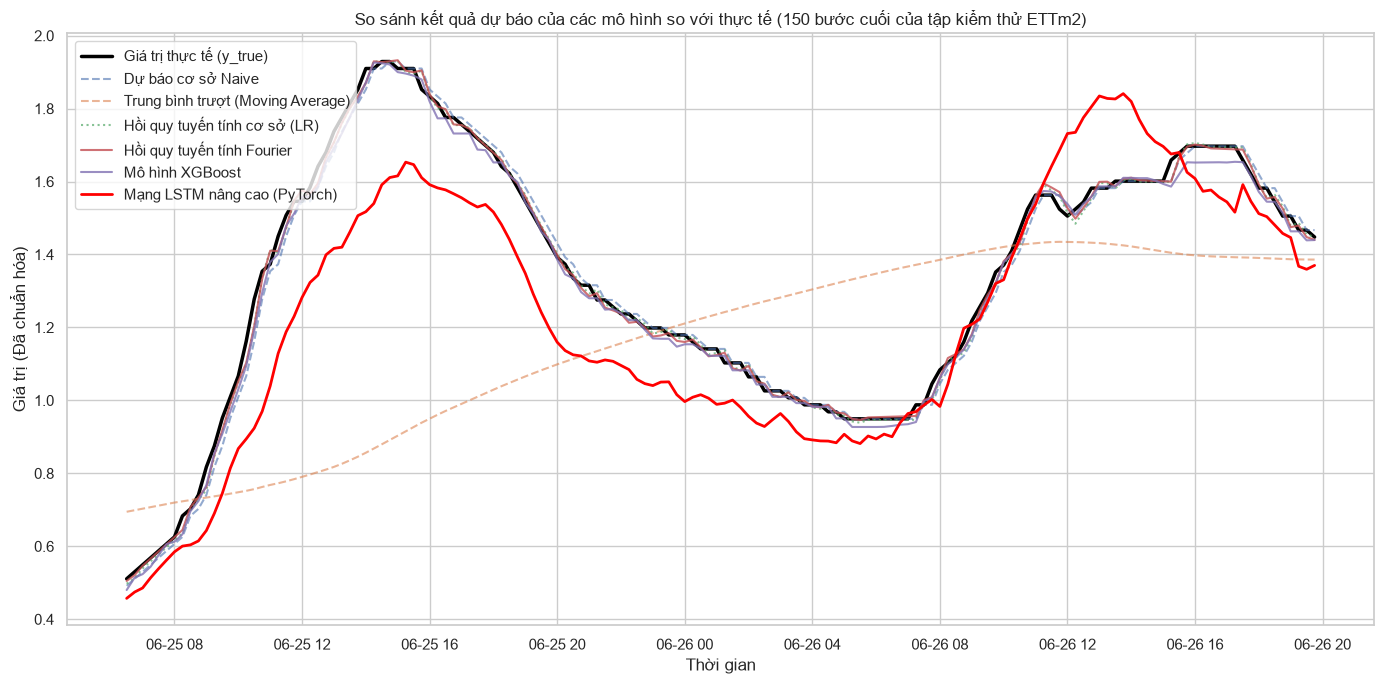

In [5]:
# Để biểu diễn rõ nét hơn, chúng ta sẽ chỉ lấy 150 bước thời gian cuối cùng của tập Test
plot_subset = pred_df.tail(150).reset_index(drop=True)

plt.figure(figsize=(14, 7))
plt.plot(plot_subset["date"], plot_subset["y_true"], label="Giá trị thực tế (y_true)", color="black", linewidth=2.5)
plt.plot(plot_subset["date"], plot_subset["naive"], label="Dự báo cơ sở Naive", linestyle="--", alpha=0.6)
plt.plot(plot_subset["date"], plot_subset["moving_average"], label="Trung bình trượt (Moving Average)", linestyle="--", alpha=0.6)
plt.plot(plot_subset["date"], plot_subset["linear_regression_baseline"], label="Hồi quy tuyến tính cơ sở (LR)", linestyle=":", alpha=0.7)
plt.plot(plot_subset["date"], plot_subset["linear_regression_fourier"], label="Hồi quy tuyến tính Fourier", alpha=0.8)
plt.plot(plot_subset["date"], plot_subset["xgboost"], label="Mô hình XGBoost", alpha=0.8)
plt.plot(plot_subset["date"], plot_subset["lstm"], label="Mạng LSTM nâng cao (PyTorch)", color="red", linewidth=2.0)

plt.title("So sánh kết quả dự báo của các mô hình so với thực tế (150 bước cuối của tập kiểm thử ETTm2)")
plt.xlabel("Thời gian")
plt.ylabel("Giá trị (Đã chuẩn hóa)")
plt.legend(loc="upper left")
plt.grid(True)
plt.tight_layout()

os.makedirs("../figures", exist_ok=True)
plt.savefig("../figures/y_true_vs_y_pred.png", dpi=300)
plt.show()